<div align="center">
  <a href="https://colab.research.google.com/github/PrunaAI/ai-efficiency-courses/blob/main/solutions/03-measure_llm_efficiency.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
  </a>
</div>

---
**💡 Tip**: Click the button above to open this notebook in Google Colab for free GPU access!

## Installation

This notebook includes automatic setup cells that will install the project from git repository with UV.

**Note**: Run the setup cells below before starting the exercises.

In [ ]:
# Install project directly from git repository
!uv pip install git+https://github.com/PrunaAI/ai-efficiency-courses.git

## Utility cells

During the course, we'll leverage some course utilities to streamline our workflow. These utilities are located in the `course` package, which can simply be imported given that we installed the project from git repository above.
You can find the source code [here](https://github.com/PrunaAI/ai-efficiency-courses/tree/main/course).

These utilities will help us:
- Load and manage lists of model ids that we have verified to work.
- Generate informative plots for model analysis.
- Iterate efficiently over evaluation and model configuration options.

Let's first load our models. We will use `SMALL_MODEL_IDS`, which are sub 1B parameters which should be easy to download and load into memory. We recommend starting with these smaller models but feel free to experiment with other models until you reach your GPU memory limit!

In [ ]:
from course import SMALL_MODEL_IDS, MEDIUM_MODEL_IDS, LARGE_MODEL_IDS, ALL_MODEL_IDS

MODEL_IDS = SMALL_MODEL_IDS
# MODEL_IDS = MEDIUM_MODEL_IDS
# MODEL_IDS = LARGE_MODEL_IDS
# MODEL_IDS = ALL_MODEL_IDS

MODEL_IDS

We also recommend to set a custom cache directory for models. Loading models can take significant disk space. To avoid filling up your default disk, we recommend setting a custom cache directory for downloaded models. You can do this by running the following in a terminal or in a notebook cell:

In [ ]:
# Replace <path_to_cache> with your desired cache path
import os

CACHE_PATH = "<path_to_cache>"
os.environ["TORCH_HOME"] = CACHE_PATH
os.environ["HF_HOME"] = CACHE_PATH
os.environ["HUGGINGFACE_HUB_CACHE"] = CACHE_PATH
os.environ["HUGGINGFACE_ASSETS_CACHE"] = CACHE_PATH

You can also clear the cache by running the following cell:

In [ ]:
from course.models import clear_cache

clear_cache(CACHE_PATH)

# 03: Measure LLM Efficiency

Welcome to the next unit of the LLM Efficiency course! 📊

In this tutorial, we will take a deep dive into how to measure the efficiency of Large Language Models (LLMs). Efficiency is a critical factor in the design, deployment, and scaling of LLMs—balancing accuracy, cost, and performance is key whether you’re running models in research, production, or edge devices. The content from the chapter 3 [slides](https://github.com/PrunaAI/ai-efficiency-courses/blob/main/slides/03-evaluate_language_models.pdf) will help you to explore this notebook.

By the end of this unit, you will:

- Understand the main dimensions of efficiency
    - quality
    - memory
    - compute
    - latency
    - energy usage
- Learn how to benchmark LLMs based on these dimensions.

Let’s dive into the world of LLM efficiency!


## 1. Imports

As we've already installed the project, we can import the necessary libraries. We will be using `transformers` for this tutorial as interface to the model and tokenizer. On top of that, we will be using `pruna` to run the evaluation. We recommend to checkout the [Pruna documentation](https://docs.pruna.ai/en/stable/docs_pruna/user_manual/evaluate.html) for access to AI efficiency functions.

In [3]:
from transformers import AutoTokenizer
from pruna.data.pruna_datamodule import PrunaDataModule
from pruna.evaluation.metrics import (
    CO2EmissionsMetric,
    DiskMemoryMetric,
    EnergyConsumedMetric,
    InferenceMemoryMetric,
    LatencyMetric,
    TorchMetricWrapper,
    TotalMACsMetric,
    TotalParamsMetric,
    TrainingMemoryMetric,
)

Beyond external libraries, this course comes with the `course` local package which contains a lot of utils that you can use in the notebooks. We will be using `evaluate_model` to evaluate a single model with the set of metrics, `create_single_plot`, `create_comparison_plots` and `create_pareto_plot` for visualizing the results.

In [4]:
from course import evaluate_model, create_single_plot, create_comparison_plots, create_pareto_front

## 2. Measure LLM efficiency

If you need help with the implementation, check out the [evaluation guide](https://docs.pruna.ai/en/stable/docs_pruna/user_manual/evaluate.html) and [metrics overview](https://docs.pruna.ai/en/stable/reference/evaluation.html#metrics-overview) in the pruna documentation.

### 2.1 Evaluate LLM Quality

In this section, you’ll learn how to benchmark large language models (LLMs) based on their quality using the perplexity metric. Perplexity is a measure of how well a model predicts a dataset by calculating the average negative log-likelihood per token.

**Why is this important?**
Evaluating quality is essential to understanding the model's capabilities and limits. However, quality highly depends on the final application (e.g. dataset, task). By focusing on perplexity, you gain a standardized way to assess predictive performance across different models, even though you still need to evaluate the model on your specific use case.

**Your tasks:**
- Evaluate the models quality using the perplexity metric on the WikiText dataset
- Visualize perplexity scores across models to spot trends related to model type and size.

**What to think about:**
- Which models have the highest perplexity? And the lowest?
- What is the relationship between the perplexity and the model size and architecture?
- What are the limits of the perplexity metric to show the model performance? Why?

In [6]:
perplexity_results = {}

metrics = [TorchMetricWrapper(metric_name="perplexity", call_type="single", device="cuda")]

### To Complete ###
for model_id in MODEL_IDS:
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    tokenizer.pad_token = tokenizer.eos_token

    # The instruct models require a max_seq_len
    datamodule = PrunaDataModule.from_string(
        dataset_name="WikiText",
        tokenizer=tokenizer,
        collate_fn_args={"max_seq_len": 512 if "instruct" in model_id.lower() else None},
    )

    model_results = evaluate_model(model_id_or_pruna_model=model_id, metrics=metrics, dataset=datamodule)
    print(f"Results for {model_id}:")
    print(model_results)
    perplexity_results[model_id] = model_results

### End of To Complete ###
create_single_plot(data_dict={model_name: perplexity_results[model_name][0].result for model_name in perplexity_results}, x_label="", y_label="perplexity", title="Perplexity by model")

INFO - Using call_type: y_gt for metric perplexity


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for facebook/opt-125m:
[MetricResult(name='perplexity', params={'_defaults': {}, 'metric': Perplexity(), 'update_fn': <function default_update at 0x71b4cb701480>, 'call_type': 'y_gt', 'metric_name': 'perplexity', 'higher_is_better': False}, result=49.46184158325195)]
Using collate_fn_args for facebook/opt-350m


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for facebook/opt-350m:
[MetricResult(name='perplexity', params={'_defaults': {}, 'metric': Perplexity(), 'update_fn': <function default_update at 0x71b4cb701480>, 'call_type': 'y_gt', 'metric_name': 'perplexity', 'higher_is_better': False}, result=39.138816833496094)]
Using collate_fn_args for HuggingFaceTB/SmolLM-135M-instruct


...

Results for HuggingFaceTB/SmolLM2-360M-Instruct:
[MetricResult(name='perplexity', params={'_defaults': {}, 'metric': Perplexity(), 'update_fn': <function default_update at 0x71b4cb701480>, 'call_type': 'y_gt', 'metric_name': 'perplexity', 'higher_is_better': False}, result=14.496500968933105)]
Using collate_fn_args for PleIAs/Pleias-350m-Preview


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for PleIAs/Pleias-350m-Preview:
[MetricResult(name='perplexity', params={'_defaults': {}, 'metric': Perplexity(), 'update_fn': <function default_update at 0x71b4cb701480>, 'call_type': 'y_gt', 'metric_name': 'perplexity', 'higher_is_better': False}, result=34.44853973388672)]
Using collate_fn_args for PleIAs/Pleias-Pico


INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using best available device: 'cuda'
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for PleIAs/Pleias-Pico:
[MetricResult(name='perplexity', params={'_defaults': {}, 'metric': Perplexity(), 'update_fn': <function default_update at 0x71b4cb701480>, 'call_type': 'y_gt', 'metric_name': 'perplexity', 'higher_is_better': False}, result=43.66575622558594)]


### 2.2 Evaluate LLM Memory

Now, you’ll measure how efficiently LLMs use memory across different stages of their lifecycle. Specifically, you’ll track disk memory, inference GPU memory, and training GPU memory.

**Why is this important?**
Memory is often the bottleneck when deploying or fine-tuning LLMs in production. Models that require a high amount of GPU memory may be too expensive or not feasible to run in real-world scenarios. Understanding memory usage helps you balance performance with operability.

**Your tasks:**
- Evaluate the models memory usage with the disk, inference, and training GPU memory metric and the WikiText dataset.
- Compare the results across models and metrics.

**What to think about:**
- Which model requires the least amount of disk memory? And the most?
- Is there a relationship between the inference and training memory usage?
- How can you reduce the memory usage of the models?

In [ ]:
memory_results = {}

### To Complete ###
metrics = [
    DiskMemoryMetric(),
    InferenceMemoryMetric(),
    TrainingMemoryMetric(),
]

for model_id in MODEL_IDS:
    model_results = evaluate_model(model_id_or_pruna_model=model_id, metrics=metrics, dataset="WikiText")
    print(f"Results for {model_id}:")
    print(model_results)
    memory_results[model_id] = model_results
### End of To Complete ###

create_comparison_plots(
    data_dict=memory_results,
    title="Memory Metrics by Model",
    x_label="Model",
    y_label="Value"
)

### 2.3 Evaluate LLM Compute

Now, let's focus on evaluating the compute efficiency of LLMs using the Multiply–Accumulate operations (MACs) and the Total Parameters metric.

**Why is this important?**
Compute cost is a major factor in both training and inference. Models with high MACs require more powerful hardware, longer runtimes, and higher operational costs. Understanding the compute requirements of different models helps you choose the right model for your use case.

**Your tasks:**
- Evaluate the models compute efficiency with the MACs and Total Parameters metric and the WikiText dataset.
- Compare the results across models and metrics.

**What to think about:**
- Which model has the lowest MACs? And the highest?
- Is there a relationship between the MACs and the model architecture? And the size?
- Is there a relationship between the Total Parameters and the MACs?

INFO - Using best available device: 'cuda'
INFO - Using max_seq_len of tokenizer: None
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for facebook/opt-125m:
[MetricResult(name='total_macs', params={'device': 'cuda:0', 'module_macs': {'OPTForCausalLM': 22375283712.0}, 'module_params': {'OPTForCausalLM': 123664896.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7bffd900ad10>}, result=22375283712.0, higher_is_better=None, metric_units=None), MetricResult(name='total_params', params={'device': 'cuda:0', 'module_macs': {'OPTForCausalLM': 22375283712.0}, 'module_params': {'OPTForCausalLM': 123664896.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7bffd900ad10>}, result=123664896.0, higher_is_better=None, metric_units=None)]


INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for facebook/opt-350m:
[MetricResult(name='total_macs', params={'device': 'cuda:0', 'module_macs': {'OPTForCausalLM': 59544354816.0}, 'module_params': {'OPTForCausalLM': 329097216.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7bffd900ad10>}, result=59544354816.0, higher_is_better=None, metric_units=None), MetricResult(name='total_params', params={'device': 'cuda:0', 'module_macs': {'OPTForCausalLM': 59544354816.0}, 'module_params': {'OPTForCausalLM': 329097216.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7bffd900ad10>}, result=329097216.0, higher_is_better=None, metric_units=None)]


INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


...

Results for HuggingFaceTB/SmolLM2-360M-Instruct:
[MetricResult(name='total_macs', params={'device': 'cuda:0', 'module_macs': {'LlamaForCausalLM': 75969331200.0}, 'module_params': {'LlamaForCausalLM': 361758720.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7bffd900ad10>}, result=75969331200.0, higher_is_better=None, metric_units=None), MetricResult(name='total_params', params={'device': 'cuda:0', 'module_macs': {'LlamaForCausalLM': 75969331200.0}, 'module_params': {'LlamaForCausalLM': 361758720.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7bffd900ad10>}, result=361758720.0, higher_is_better=None, metric_units=None)]


INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for PleIAs/Pleias-350m-Preview:
[MetricResult(name='total_macs', params={'device': 'cuda:0', 'module_macs': {'LlamaForCausalLM': 68907171840.0}, 'module_params': {'LlamaForCausalLM': 353370112.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7bffd900ad10>}, result=68907171840.0, higher_is_better=None, metric_units=None), MetricResult(name='total_params', params={'device': 'cuda:0', 'module_macs': {'LlamaForCausalLM': 68907171840.0}, 'module_params': {'LlamaForCausalLM': 353370112.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7bffd900ad10>}, result=353370112.0, higher_is_better=None, metric_units=None)]


INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for PleIAs/Pleias-Pico:
[MetricResult(name='total_macs', params={'device': 'cuda:0', 'module_macs': {'LlamaForCausalLM': 68907171840.0}, 'module_params': {'LlamaForCausalLM': 353370112.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7bffd900ad10>}, result=68907171840.0, higher_is_better=None, metric_units=None), MetricResult(name='total_params', params={'device': 'cuda:0', 'module_macs': {'LlamaForCausalLM': 68907171840.0}, 'module_params': {'LlamaForCausalLM': 353370112.0}, 'call_tracker': <pruna.engine.call_sequence_tracker.CallSequenceTracker object at 0x7bffd900ad10>}, result=353370112.0, higher_is_better=None, metric_units=None)]


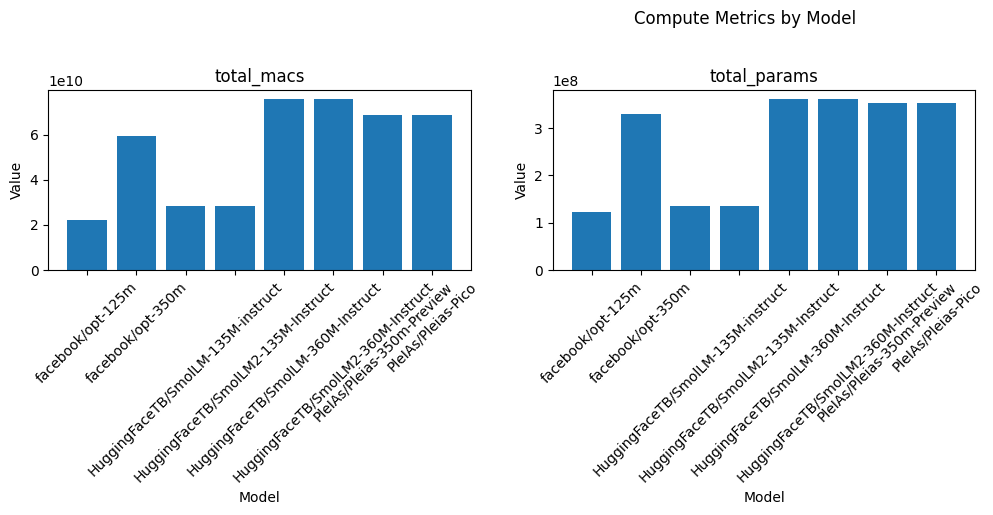

In [5]:
compute_results = {}

### To Complete ###
metrics = [
    TotalMACsMetric(device="cuda"),
    TotalParamsMetric(device="cuda"),
]

for model_id in MODEL_IDS:
    model_results = evaluate_model(model_id_or_pruna_model=model_id, metrics=metrics, dataset="WikiText")
    print(f"Results for {model_id}:")
    print(model_results)
    compute_results[model_id] = model_results

create_comparison_plots(
    data_dict=compute_results,
    title="Compute Metrics by Model",
    x_label="Model",
    y_label="Value"
)
### End of To Complete ###

### 2.4 Evaluate LLM Latency

For the next section, you’ll measure how quickly LLMs generate outputs by benchmarking them with the latency metric. Latency captures the time it takes for a model to process inputs and produce results.

**Why is this important?**
A model that produces excellent results but takes too long to respond may be unusable in production (e.g. chatbots, real-time translation, etc.). Understanding the latency of the models helps you to build responsive and efficient systems.

**Your tasks:**
- Measure the latency of each model witht the WikiText dataset.
- Visualize latency across models.

**What to think about:**
- Which model has the lowest latency? And the highest?
- Is there a relationship between the latency and the model architecture? And the size?
- How does latency differ across hardware (CPU vs GPU)?

In [32]:
latency_results = {}

### To Complete ###
metrics = [
    LatencyMetric(
        n_iterations=10,
        n_warmup_iterations=10,
        device="cuda",
    ),
]

for model_id in MODEL_IDS:
    model_results = evaluate_model(model_id_or_pruna_model=model_id, metrics=metrics, dataset="WikiText")
    print(f"Results for {model_id}:")
    print(model_results)
    latency_results[model_id] = model_results

create_single_plot(data_dict={model_name: latency_results[model_name][0].result for model_name in latency_results}, x_label="", y_label="Latency", title="Latency by model")
### End of To Complete ###

INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for facebook/opt-125m:
[MetricResult(name='latency', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0', 'timing_type': 'sync', 'batch_size': 1}, result=3.003008008003235)]


INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for facebook/opt-350m:
[MetricResult(name='latency', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0', 'timing_type': 'sync', 'batch_size': 1}, result=5.635190391540528)]


INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


...

Results for HuggingFaceTB/SmolLM2-360M-Instruct:
[MetricResult(name='latency', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0', 'timing_type': 'sync', 'batch_size': 1}, result=16.635634994506837)]


INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for PleIAs/Pleias-350m-Preview:
[MetricResult(name='latency', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0', 'timing_type': 'sync', 'batch_size': 1}, result=13.519206333160401)]


INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.


Results for PleIAs/Pleias-Pico:
[MetricResult(name='latency', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0', 'timing_type': 'sync', 'batch_size': 1}, result=13.64968318939209)]


### 2.5 Evaluate LLM Energy Consumption

This time, you’ll evaluate the energy efficiency of LLMs by benchmarking them with metrics that track both energy usage and CO₂ emissions.

**Why is this important?**
Training and running LLMs consume substantial amounts of energy, which translates into both financial cost and environmental impact. As sustainability becomes an increasingly important consideration in AI development, understanding the energy footprint of your models is critical for responsible deployment.

**Your tasks:**
- Evaluate the models to measure each model’s energy usage.
- Compare the results across models and metrics.

**What to think about:**
- Which model type consumes the least energy?
- Which model size produces the lowest emissions?
- When is measuring energy and CO₂ particularly useful?
- What are the limitations of these metrics in representing overall efficiency?

INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.
[codecarbon WARNING @ 16:03:35] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 16:03:35] [setup] RAM Tracking...
[codecarbon INFO @ 16:03:35] [setup] CPU Tracking...
[codecarbon WARNING @ 16:03:36] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at

Results for facebook/opt-125m:
[MetricResult(name='energy_consumed', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0'}, result=7.026438232328225e-05, higher_is_better=None, metric_units=None), MetricResult(name='co2_emissions', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0'}, result=3.937545721014414e-06, higher_is_better=None, metric_units=None)]


INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.
[codecarbon WARNING @ 16:03:46] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 16:03:46] [setup] RAM Tracking...
[codecarbon INFO @ 16:03:46] [setup] CPU Tracking...
[codecarbon WARNING @ 16:03:47] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at

Results for facebook/opt-350m:
[MetricResult(name='energy_consumed', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0'}, result=7.985378196182081e-05, higher_is_better=None, metric_units=None), MetricResult(name='co2_emissions', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0'}, result=4.474926087358477e-06, higher_is_better=None, metric_units=None)]


INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.
[codecarbon WARNING @ 16:03:57] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 16:03:57] [setup] RAM Tracking...
[codecarbon INFO @ 16:03:57] [setup] CPU Tracking...
[codecarbon WARNING @ 16:03:58] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon INFO @ 16:03:58] CPU Model on constant consumption mode: AMD EPYC 9334 

...

Results for HuggingFaceTB/SmolLM2-360M-Instruct:
[MetricResult(name='energy_consumed', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0'}, result=8.477444998364488e-05, higher_is_better=None, metric_units=None), MetricResult(name='co2_emissions', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0'}, result=4.750675402633476e-06, higher_is_better=None, metric_units=None)]


INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.
[codecarbon WARNING @ 16:04:41] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 16:04:41] [setup] RAM Tracking...
[codecarbon INFO @ 16:04:41] [setup] CPU Tracking...
[codecarbon WARNING @ 16:04:41] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at

Results for PleIAs/Pleias-350m-Preview:
[MetricResult(name='energy_consumed', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0'}, result=8.079796333229792e-05, higher_is_better=None, metric_units=None), MetricResult(name='co2_emissions', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0'}, result=4.5278370671786435e-06, higher_is_better=None, metric_units=None)]


INFO - Using best available device: 'cuda'
INFO - Testing compatibility with text_generation_collate...
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.
INFO - Using provided list of metric instances.
INFO - Using best available device: 'cuda'
INFO - Evaluating a base model.
INFO - Detected transformers model. Using TransformerHandler.
- The first element of the batch is passed as input.
- The generated outputs are expected to have .logits attribute.
INFO - Evaluating stateful metrics.
INFO - Evaluating isolated inference metrics.
[codecarbon WARNING @ 16:04:52] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 16:04:52] [setup] RAM Tracking...
[codecarbon INFO @ 16:04:52] [setup] CPU Tracking...
[codecarbon WARNING @ 16:04:52] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at

Results for PleIAs/Pleias-Pico:
[MetricResult(name='energy_consumed', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0'}, result=8.079000450593361e-05, higher_is_better=None, metric_units=None), MetricResult(name='co2_emissions', params={'n_iterations': 10, 'n_warmup_iterations': 10, 'device': 'cuda:0'}, result=4.527391062508014e-06, higher_is_better=None, metric_units=None)]


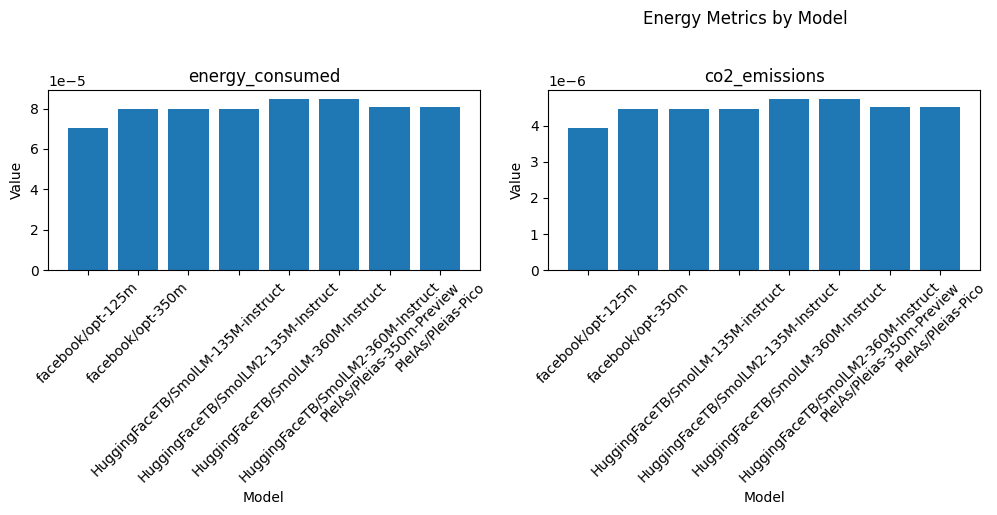

In [6]:
energy_results = {}

### To Complete ###
metrics = [
    EnergyConsumedMetric(
        n_iterations=10,
        n_warmup_iterations=10,
        device="cuda",
    ),
    CO2EmissionsMetric(
        n_iterations=10,
        n_warmup_iterations=10,
        device="cuda",
    ),
]

for model_id in MODEL_IDS:
    model_results = evaluate_model(model_id_or_pruna_model=model_id, metrics=metrics, dataset="WikiText")
    print(f"Results for {model_id}:")
    print(model_results)
    energy_results[model_id] = model_results

create_comparison_plots(
    data_dict=energy_results,
    title="Energy Metrics by Model",
    x_label="Model",
    y_label="Value"
)
### End of To Complete ###

### 2.6 Evaluate LLM Trade-offs

Finally, you’ll bring together all the evaluation results from previous metrics—quality, memory, compute, latency, and energy—and visualize them and evaluate the models that achieves the best trade-offs.

**Why is this important?**
No single model dominates across every efficiency dimension. Plotting results provides a general view of trade-offs, enabling you to identify models that are efficiently optimal and balanced.

**Your tasks:**
- Create a function that takes the results from the previous metrics and returns a dictionary with the results to be plotted.
- Plot the results on a Pareto front and analyze the trade-offs. Test with different metrics.

**What to think about:**
- What is the best model on the Pareto front?
- Is there a relationship between the metrics?
- How do the results change when the architecture is different?

In [47]:
from collections import defaultdict

def plot_pareto_front(metric1_results: dict, metric2_results: dict, metric1_name: str, metric2_name: str) -> None:
    """
    Plot the Pareto front for two metrics using the `create_pareto_front` function.

    Args:
        metric1_results: Dictionary with the results of the first metric.
        metric2_results: Dictionary with the results of the second metric.
        metric1_name: Name of the first metric.
        metric2_name: Name of the second metric.
    """
    results = defaultdict(dict)

    ### To Complete ###
    for model, metrics in metric1_results.items():
        for metric in metrics:
            results[model][metric.name] = metric.result

    for model, metrics in metric2_results.items():
        for metric in metrics:
            results[model][metric.name] = metric.result

    #### End of To Complete ####
    create_pareto_front(results, metric1_name, metric2_name)

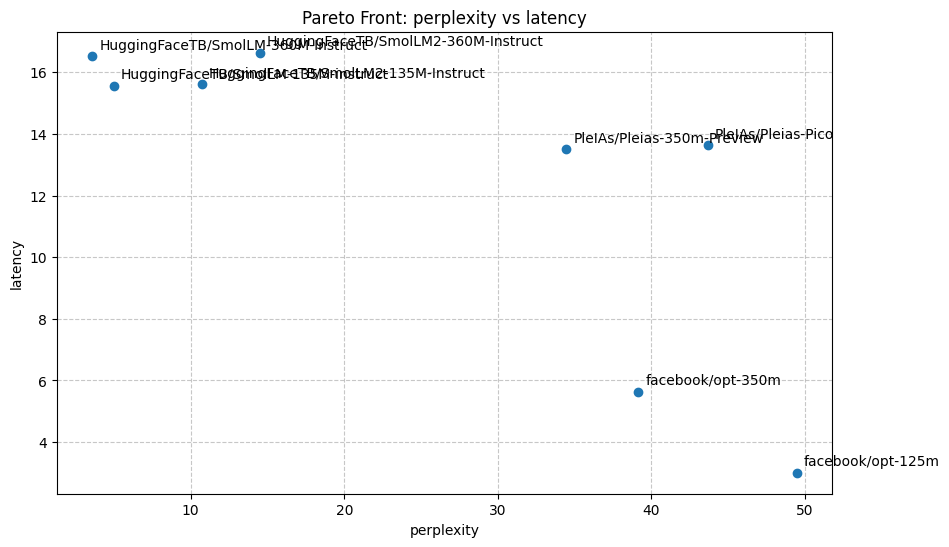

In [48]:
plot_pareto_front(perplexity_results, latency_results, "perplexity", "latency")

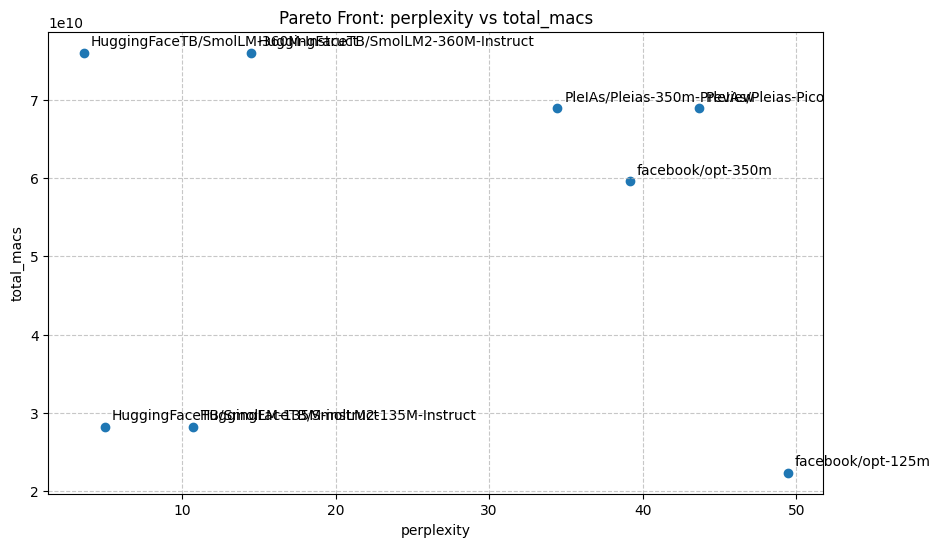

In [51]:
### To Complete ###
plot_pareto_front(perplexity_results, compute_results, "perplexity", "total_macs") # or total_params
### End of To Complete ###

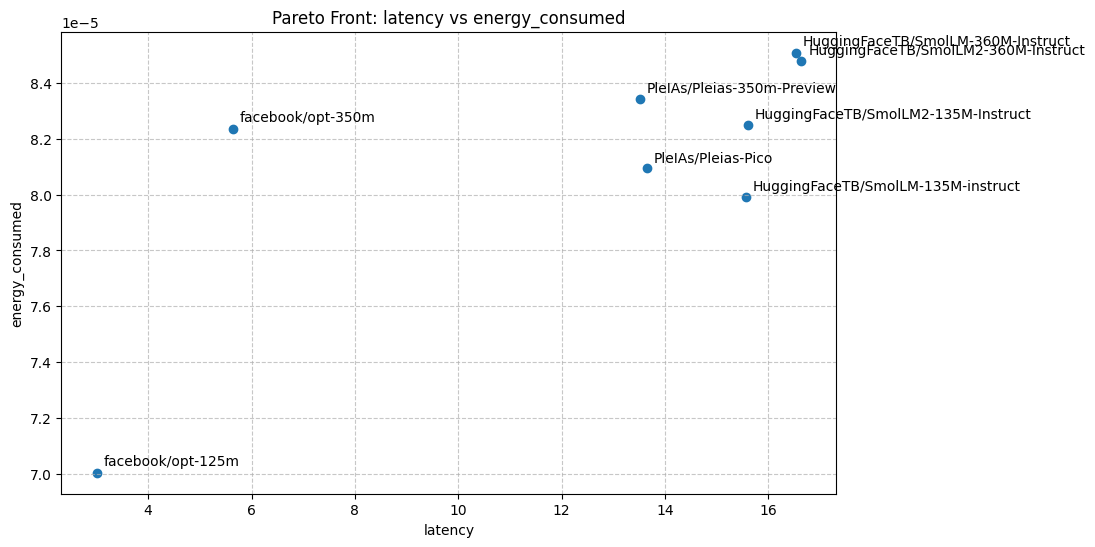

In [52]:
plot_pareto_front(latency_results, energy_results, "latency", "energy_consumed") # or co2_emissions

## Conclusion: What We've Learned About Measuring LLM Efficiency

In this module, we explored how to measure the efficiency of LLMs. Here’s a recap of the key concepts:

- **Efficiency Metrics Dimensions:**
    - Quality: Even if it might be difficult to measure, it is important to have a metric to evaluate and then adapt it to the needs of the application.
    - Memory: Memory influences the cost and resource usage of the model. A high memory usage can be a problem for real-world deployment.
    - Compute: Models with high compute requirements can be expensive to run and have a high carbon footprint.
    - Latency: The reponse speed of the model is critical for real-world use-cases.
    - Energy: To save costs and reduce the carbon footprint of the model, it is important to consider the energy consumption of the model.
- **Deployment Considerations:**
    - The trade-offs between the different metrics are not always clear.
    - The Pareto front can be used to identify the best trade-offs between the different metrics. Based on your use-case, you can select the best model for your needs.


### Next Steps: Quantization

Now that you understand how to measure the efficiency of LLMs, the next segment will focus on **quantization**. You’ll learn about quantization methods and how they influence the efficiency of the model.

👉 **Continue to the next notebook:**  
[04-benchmark_llm_quantization_methods.ipynb on GitHub](https://github.com/PrunaAI/ai-efficiency-courses/blob/main/exercises/04-benchmark_llm_quantization_methods.ipynb)

## ⭐ Bonus Exercise: Measure LLM Efficiency across Context Lengths

As a bonus, extend your analysis to explore how LLM efficiency changes when the context length varies. Context length determines how many tokens a model can process at once, and it has a significant impact on quality, latency, compute, and memory usage. By analyzing efficiency across different context lengths, you’ll uncover how models scale with longer inputs.

**Your tasks:**

1. Benchmark models across different context lengths:
    Modify the evaluation function and run the models with varying context lengths.
2.	Compare scaling behavior:
    Identify how different model types and sizes handle longer contexts, and plot the results to visualize scaling trends.

**What to think about:**
- Which model handles longer contexts most efficiently?
- How do quality and efficiency trade-offs evolve as context length increases?